## Task 1: Data Preprocessing

### Import Necessary Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import torch
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

### Load the data & keep the relevant column

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Read the training, testing, and validation datasets from LIAR dataset
train = pd.read_csv("/content/drive/MyDrive/FactOrFiction/train.tsv", sep="\t", header=None)
validation = pd.read_csv("/content/drive/MyDrive/FactOrFiction/valid.tsv", sep="\t", header=None)
test = pd.read_csv("/content/drive/MyDrive/FactOrFiction/test.tsv", sep="\t", header=None)

In [ ]:
# Print the data
print(train.head())
print(validation.head())
print(test.head())

           0            1                                                  2   \
0   2635.json        false  Says the Annies List political group supports ...   
1  10540.json    half-true  When did the decline of coal start? It started...   
2    324.json  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3   1123.json        false  Health care reform legislation is likely to ma...   
4   9028.json    half-true  The economic turnaround started at the end of ...   

                                   3               4                     5   \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

         6           7     8     9    

In [ ]:
# Check the shapes of the datasets
print("Shape of TRAIN DATA: ", train.shape)
print("Shape of VALIDATION DATA: ", validation.shape)
print("Shape of TEST DATA: ", test.shape)

Shape of TRAIN DATA:  (10240, 14)
Shape of VALIDATION DATA:  (1284, 14)
Shape of TEST DATA:  (1267, 14)


In [ ]:
# Keep every column except 6
train = train[[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]]
validation = validation[[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]]
test = test[[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12]]

cols = ['label', 'statement', 'subject', 'speaker', 'job', 'party', 'pants_fire_counts', 'false_counts', 'barely_true_counts', 'half_true_counts', 'true_counts']
train.columns = cols
validation.columns = cols
test.columns = cols

In [ ]:
# Print the updated data
print(train.head())
print(validation.head())
print(test.head())

         label                                          statement  \
0        false  Says the Annies List political group supports ...   
1    half-true  When did the decline of coal start? It started...   
2  mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3        false  Health care reform legislation is likely to ma...   
4    half-true  The economic turnaround started at the end of ...   

                              subject         speaker                   job  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   
2                      foreign-policy    barack-obama             President   
3                         health-care    blog-posting                   NaN   
4                        economy,jobs   charlie-crist                   NaN   

        party  pants_fire_counts  false_counts  barely_true_counts  \
0  republican                0.0        

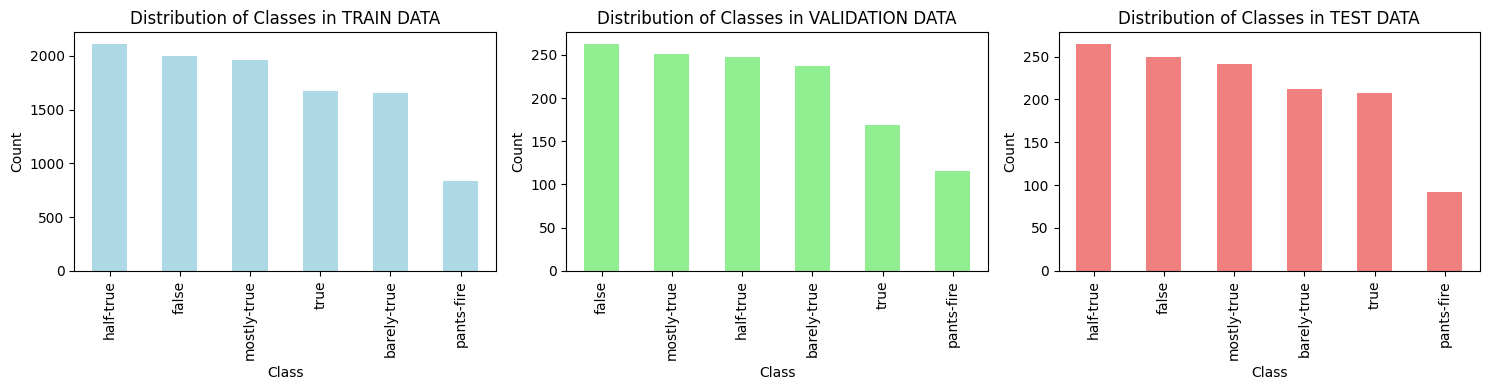

In [ ]:
# Plot the distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

train['label'].value_counts().plot(kind='bar', ax=axes[0], color='lightblue')
axes[0].set_title('Distribution of Classes in TRAIN DATA')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

validation['label'].value_counts().plot(kind='bar', ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Classes in VALIDATION DATA')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

test['label'].value_counts().plot(kind='bar', ax=axes[2], color='lightcoral')
axes[2].set_title('Distribution of Classes in TEST DATA')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Count')


plt.tight_layout()
plt.show()

### Data Cleaning
Reference: https://www.geeksforgeeks.org/machine-learning/python-efficient-text-data-cleaning/

In [ ]:
train_clean = train.copy()
validation_clean = validation.copy()
test_clean = test.copy()

In [ ]:
def combine_fields(row):
    # Use every field except 6
    parts = [
      f"speaker: {row['speaker']}",
      f"party: {row['party']}",
      f"job: {row['job']}",
      f"subject: {row['subject']}",
      f"history: {row['pants_fire_counts']} pants-fire, {row['false_counts']} false, {row['barely_true_counts']} barely-true, {row['half_true_counts']} half-true, {row['true_counts']} true",
      f"statement: {row['statement']}"
    ]
    # Handle NaN values gracefully
    parts = [p for p in parts if 'nan' not in p.lower()]
    return ' '.join(parts)

train_clean['text'] = train.apply(combine_fields, axis=1)
validation_clean['text'] = validation.apply(combine_fields, axis=1)
test_clean['text'] = test.apply(combine_fields, axis=1)

In [ ]:
def clean_text(text):
    # Step 1: Convert all text to lowercase, remove punctuation and remove whitespace
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())

    # Step 2: Remove URLs and Hashtags
    text = re.sub(r'https?:\/\/.\S+', "", text)
    text = re.sub(r'#', '', text)

    # Step 3: Contration Replacement (didn't to did not)
    shorten_dict={"'s":" is","n't":" not","'m":" am","'ll":" will",
           "'d":" would","'ve":" have","'re":" are"}
    for key, value in shorten_dict.items():
        if key in text:
            text = text.replace(key, value)

    return text

In [ ]:
train_clean['text'] = train_clean['text'].apply(clean_text)
validation_clean['text'] = validation_clean['text'].apply(clean_text)
test_clean['text'] = test_clean['text'].apply(clean_text)

In [ ]:
print(train_clean)

             label                                          statement  \
0            false  Says the Annies List political group supports ...   
1        half-true  When did the decline of coal start? It started...   
2      mostly-true  Hillary Clinton agrees with John McCain "by vo...   
3            false  Health care reform legislation is likely to ma...   
4        half-true  The economic turnaround started at the end of ...   
...            ...                                                ...   
10235  mostly-true  There are a larger number of shark attacks in ...   
10236  mostly-true  Democrats have now become the party of the [At...   
10237    half-true  Says an alternative to Social Security that op...   
10238        false  On lifting the U.S. Cuban embargo and allowing...   
10239   pants-fire  The Department of Veterans Affairs has a manua...   

                                  subject         speaker  \
0                                abortion    dwayne-bohac   
1

In [ ]:
print(train_clean['text'])

0        speaker dwaynebohac party republican job state...
1        speaker scottsurovell party democrat job state...
2        speaker barackobama party democrat job preside...
3        speaker blogposting party none subject healthc...
4        speaker charliecrist party democrat subject ec...
                               ...                        
10235    speaker acluflorida party none subject animals...
10236    speaker alanpowell party republican subject el...
10237    speaker hermancain party republican subject re...
10238    speaker jeffgreene party democrat subject flor...
10239    speaker michaelsteele party republican job cha...
Name: text, Length: 10240, dtype: object


In [ ]:
print("Train distribution:")
print(train_clean['label'].value_counts())
print(train_clean['label'].value_counts(normalize=True))

print("\nTest distribution:")
print(test_clean['label'].value_counts())
print(test_clean['label'].value_counts(normalize=True))

Train distribution:
label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64
label
half-true      0.206445
false          0.194824
mostly-true    0.191602
true           0.163672
barely-true    0.161523
pants-fire     0.081934
Name: proportion, dtype: float64

Test distribution:
label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64
label
half-true      0.209155
false          0.196527
mostly-true    0.190213
barely-true    0.167324
true           0.164167
pants-fire     0.072612
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# Show full content of each column
pd.set_option('display.max_colwidth', None)

# Now print the DataFrame
print(train.head())

         label  \
0        false   
1    half-true   
2  mostly-true   
3        false   
4    half-true   

                                                                                                                                       statement  \
0                                                             Says the Annies List political group supports third-trimester abortions on demand.   
1  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.   
2                                      Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."   
3                                                                 Health care reform legislation is likely to mandate free sex change surgeries.   
4                                                                                         The economic turnaround started at the end of my term.   

  

In [ ]:
import pandas as pd

# Show full content of each column
pd.set_option('display.max_colwidth', None)

# Now print the DataFrame
print(train_clean.head())

         label  \
0        false   
1    half-true   
2  mostly-true   
3        false   
4    half-true   

                                                                                                                                       statement  \
0                                                             Says the Annies List political group supports third-trimester abortions on demand.   
1  When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.   
2                                      Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."   
3                                                                 Health care reform legislation is likely to mandate free sex change surgeries.   
4                                                                                         The economic turnaround started at the end of my term.   

  

## Task 2: BiLSTM Baseline


Reference: https://www.geeksforgeeks.org/nlp/bidirectional-lstm-in-nlp/ -> but ours are not just true or false so we can't use vectorization


### Encode Labels
Convert the labels such as false, true, etc. into numbers


In [ ]:
from sklearn.preprocessing import LabelEncoder
""" Old (6-class) classifications
label_encoder = LabelEncoder()

train_labels = label_encoder.fit_transform(train_clean[1])
val_labels = label_encoder.transform(validation_clean[1])
test_labels = label_encoder.transform(test_clean[1])
"""
# New binary label mappings:
label_map = {
    'pants-fire': 0,
    'false':      0,
    'barely-true':0,
    'half-true':  1,
    'mostly-true':1,
    'true':       1
}

train_labels      = train_clean['label'].map(label_map).values
val_labels        = validation_clean['label'].map(label_map).values
test_labels       = test_clean['label'].map(label_map).values

#print(label_encoder.classes_)

### Tokenization

In [ ]:
MAX_VOCAB = 10000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean['text'])

train_seq = tokenizer.texts_to_sequences(train_clean['text'])
val_seq = tokenizer.texts_to_sequences(validation_clean['text'])
test_seq = tokenizer.texts_to_sequences(test_clean['text'])

train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post')
val_pad = pad_sequences(val_seq, maxlen=MAX_LEN, padding='post')
test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post')

### Train the BiLSTM
Reference: https://medium.com/@anishnama20/understanding-bidirectional-lstm-for-sequential-data-processing-b83d6283befc

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from keras.regularizers import l2

# Define the model architecture
model = Sequential()

# Add an embedding layer to convert input sequences to dense vectors
model.add(Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN))

# Add a Bidirectional LSTM layer with higher dropout
model.add(Bidirectional(LSTM(units=64, dropout=0.4, recurrent_dropout=0.4, return_sequences=False)))

# Add an explicit dropout layer
model.add(Dropout(0.5))

# Add a dense output layer with L2 regularization to constrain weights
model.add(Dense(units=64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation='sigmoid')) # Changed with binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_pad, train_labels,
    validation_data=(val_pad, val_labels),
    epochs=5,
    batch_size=32
)

Epoch 1/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 53s 139ms/step - accuracy: 0.5831 - loss: 0.8222 - val_accuracy: 0.6075 - val_loss: 0.6708
Epoch 2/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 43s 134ms/step - accuracy: 0.6614 - loss: 0.6303 - val_accuracy: 0.6347 - val_loss: 0.6632
Epoch 3/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 43s 134ms/step - accuracy: 0.7197 - loss: 0.5696 - val_accuracy: 0.5927 - val_loss: 0.8378
Epoch 4/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 43s 134ms/step - accuracy: 0.7611 - loss: 0.5128 - val_accuracy: 0.5818 - val_loss: 0.9116
Epoch 5/5
320/320 ━━━━━━━━━━━━━━━━━━━━ 43s 133ms/step - accuracy: 0.7969 - loss: 0.4565 - val_accuracy: 0.5872 - val_loss: 0.8889


In [ ]:
test_loss, test_acc = model.evaluate(test_pad, test_labels)
print(f"Test Accuracy: {test_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5864 - loss: 0.9384
Test Accuracy: 0.5864


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get BiLSTM predictions on the test set
bilstm_predictions_prob = model.predict(test_pad)
bilstm_predictions = (bilstm_predictions_prob > 0.5).astype(int).flatten()

# Calculate BiLSTM metrics
bilstm_precision = precision_score(test_labels, bilstm_predictions)
bilstm_recall = recall_score(test_labels, bilstm_predictions)
bilstm_f1 = f1_score(test_labels, bilstm_predictions)

print(f"BiLSTM Precision: {bilstm_precision:.4f}")
print(f"BiLSTM Recall: {bilstm_recall:.4f}")
print(f"BiLSTM F1-Score: {bilstm_f1:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
BiLSTM Precision: 0.6439
BiLSTM Recall: 0.5952
BiLSTM F1-Score: 0.6186


## Task 3: BERT

Reference:

- https://medium.com/@info.codetitan/analyzing-fake-news-with-transformers-484b537c6f0e
- https://medium.com/@piyushkashyap045/guide-to-tokenization-and-padding-with-bert-transforming-text-into-machine-readable-data-5a24bf59d36b

- https://medium.com/data-science/a-complete-guide-to-bert-with-code-9f87602e4a11 (most relevant to the code)

### Tokenize the text

In [ ]:
# Load a BERT tokenizer
""" Changed for Roberta-large
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
"""
bert_tokenizer = RobertaTokenizer.from_pretrained("roberta-large") # Change 9
# Tokenize the training data
train_tokens = bert_tokenizer(
    train_clean['text'].tolist(),
    padding=True,
    truncation=True,
    max_length = 128)

# Tokenize the validation data
val_tokens = bert_tokenizer(
    validation_clean['text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length = 128)

# Tokenize the test data
test_tokens = bert_tokenizer(
    test_clean['text'].tolist(),
    padding='max_length',
    truncation=True,
    max_length = 128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def make_dataloader(tokens, labels, batch_size=32, shuffle=True):
    input_ids      = torch.tensor(tokens["input_ids"])
    attention_mask = torch.tensor(tokens["attention_mask"])
    label_tensor   = torch.tensor(labels)
    dataset = TensorDataset(input_ids, attention_mask, label_tensor)
    sampler = RandomSampler(dataset) if shuffle else SequentialSampler(dataset)
    return DataLoader(dataset, sampler=sampler, batch_size=batch_size)

train_dataloader = make_dataloader(train_tokens, train_labels, shuffle=True)
val_dataloader   = make_dataloader(val_tokens,   val_labels,   shuffle=False)
test_dataloader  = make_dataloader(test_tokens,  test_labels,  shuffle=False)

### Train the BERT model

In [ ]:
from torch.optim import AdamW
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

EPOCHS = 10 # Change as needed
device = torch.device("cuda")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model - Bert Model
"""
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2 ) # Changed for binary and for dropout
"""
# Load model - RoBERTa
bert_model = RobertaForSequenceClassification.from_pretrained(
    'roberta-large',
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
)

bert_model.to(device)

"""
# Freeze bottom 6 layers
for name, param in bert_model.named_parameters():
    if any(f"encoder.layer.{i}." in name for i in range(6)):
        param.requires_grad = False

# Optimizer with freezing
optimizer = AdamW(
    filter(lambda p: p.requires_grad, bert_model.parameters()),
    lr=2e-5
)
"""
# Optimizer with differential learning rates
optimizer = AdamW([
    #{"params": bert_model.bert.parameters(), "lr": 2e-5},
    {"params": bert_model.roberta.parameters(), "lr": 1e-5}, # Change 9
    {"params": bert_model.classifier.parameters(), "lr": 1e-3}
])


# Loss function
loss_function = nn.CrossEntropyLoss()

# Scheduler
num_training_steps = EPOCHS * len(train_dataloader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def calculate_accuracy(preds, labels):
    """ Calculate the accuracy of model predictions against true labels.

    Parameters:
        preds (np.array): The predicted label from the model
        labels (np.array): The true label

    Returns:
        accuracy (float): The accuracy as a percentage of the correct
            predictions.
    """
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    accuracy = np.sum(pred_flat == labels_flat) / len(labels_flat)

    return accuracy

In [ ]:
# Training loop
best_val_loss = float('inf')
patience = 5
epochs_without_improvement = 0

# Initialize lists to store metrics
train_accuracy_history = []
val_accuracy_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(0, EPOCHS):
    print(f"Epoch: {epoch+1}/{EPOCHS}")
    bert_model.train()
    training_loss = 0
    training_accuracy = 0

    for batch in train_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        bert_model.zero_grad()

        loss, logits = bert_model(
            batch_token_ids,
            token_type_ids = None,
            attention_mask=batch_attention_mask,
            labels=batch_labels,
            return_dict=False)

        training_loss += loss.item()
        logits_np = logits.detach().cpu().numpy()
        labels_np = batch_labels.detach().cpu().numpy()
        training_accuracy += calculate_accuracy(logits_np, labels_np)

        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    average_train_loss = training_loss / len(train_dataloader)
    avg_train_acc = training_accuracy / len(train_dataloader)

    # Model validation
    bert_model.eval()
    val_loss = 0
    val_accuracy = 0

    for batch in val_dataloader:

        batch_token_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        with torch.no_grad():
            (loss, logits) = bert_model(
                batch_token_ids,
                attention_mask = batch_attention_mask,
                labels = batch_labels,
                token_type_ids = None,
                return_dict=False)

        logits = logits.detach().cpu().numpy()
        label_ids = batch_labels.to('cpu').numpy()
        val_loss += loss.item()
        val_accuracy += calculate_accuracy(logits, label_ids)

    average_val_accuracy = val_accuracy / len(val_dataloader)
    average_val_loss = val_loss / len(val_dataloader)

    # Store metrics for plotting
    train_accuracy_history.append(avg_train_acc)
    val_accuracy_history.append(average_val_accuracy)
    train_loss_history.append(average_train_loss)
    val_loss_history.append(average_val_loss)

    # Stop training when validation loss gets worse
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        torch.save(bert_model.state_dict(), 'best_model.pt')
        epochs_without_improvement = 0
        print(f"New best model saved!")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Training Loss: {average_train_loss:.4f}")
    print(f"Training Accuracy: {avg_train_acc:.4f}")
    print(f"Validation Loss: {average_val_loss:.4f}")
    print(f"Validation Accuracy: {average_val_accuracy:.4f}")

Epoch: 1/10
New best model saved!
Training Loss: 0.7076
Training Accuracy: 0.5359
Validation Loss: 0.6864
Validation Accuracy: 0.5389
Epoch: 2/10
New best model saved!
Training Loss: 0.6169
Training Accuracy: 0.6397
Validation Loss: 0.5888
Validation Accuracy: 0.6829
Epoch: 3/10
New best model saved!
Training Loss: 0.5481
Training Accuracy: 0.7020
Validation Loss: 0.5654
Validation Accuracy: 0.7409
Epoch: 4/10
Training Loss: 0.5238
Training Accuracy: 0.7149
Validation Loss: 0.5686
Validation Accuracy: 0.7111
Epoch: 5/10
New best model saved!
Training Loss: 0.5100
Training Accuracy: 0.7255
Validation Loss: 0.5596
Validation Accuracy: 0.7020
Epoch: 6/10
Training Loss: 0.4940
Training Accuracy: 0.7349
Validation Loss: 0.5837
Validation Accuracy: 0.6776
Epoch: 7/10
New best model saved!
Training Loss: 0.4827
Training Accuracy: 0.7519
Validation Loss: 0.5440
Validation Accuracy: 0.7248
Epoch: 8/10
Training Loss: 0.4689
Training Accuracy: 0.7625
Validation Loss: 0.5456
Validation Accuracy: 0

In [ ]:
bert_model.load_state_dict(torch.load('best_model.pt'))
bert_model.eval()
test_accuracy = 0

for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask
        )

    logits = outputs.logits
    logits = logits.detach().cpu().numpy()
    label_ids = batch_labels.cpu().numpy()

    test_accuracy += calculate_accuracy(logits, label_ids)

print(f"Test Accuracy: {test_accuracy / len(test_dataloader):.4f}")

Test Accuracy: 0.7067


<Figure size 800x600 with 0 Axes>

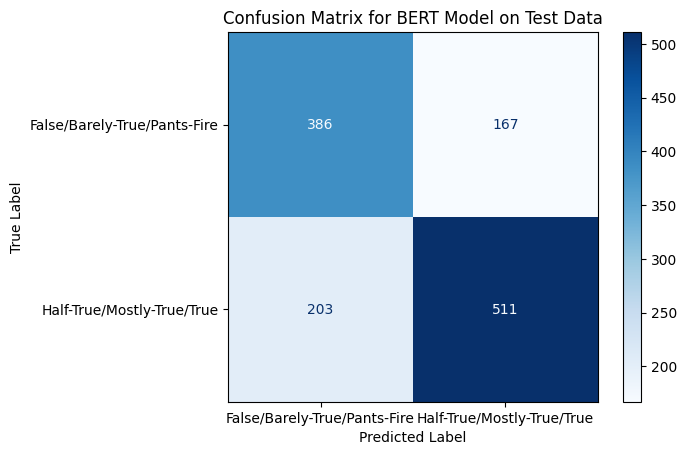

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the test set
bert_model.eval()
all_predictions = []
all_true_labels = []

for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask
        )

    logits = outputs.logits
    predictions = torch.argmax(logits, dim=1).cpu().numpy()
    true_labels = batch_labels.cpu().numpy()

    all_predictions.extend(predictions)
    all_true_labels.extend(true_labels)

# Calculate the confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Define class labels for the confusion matrix (0 for 'false' categories, 1 for 'true' categories)
class_names = ['False/Barely-True/Pants-Fire', 'Half-True/Mostly-True/True']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for BERT Model on Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

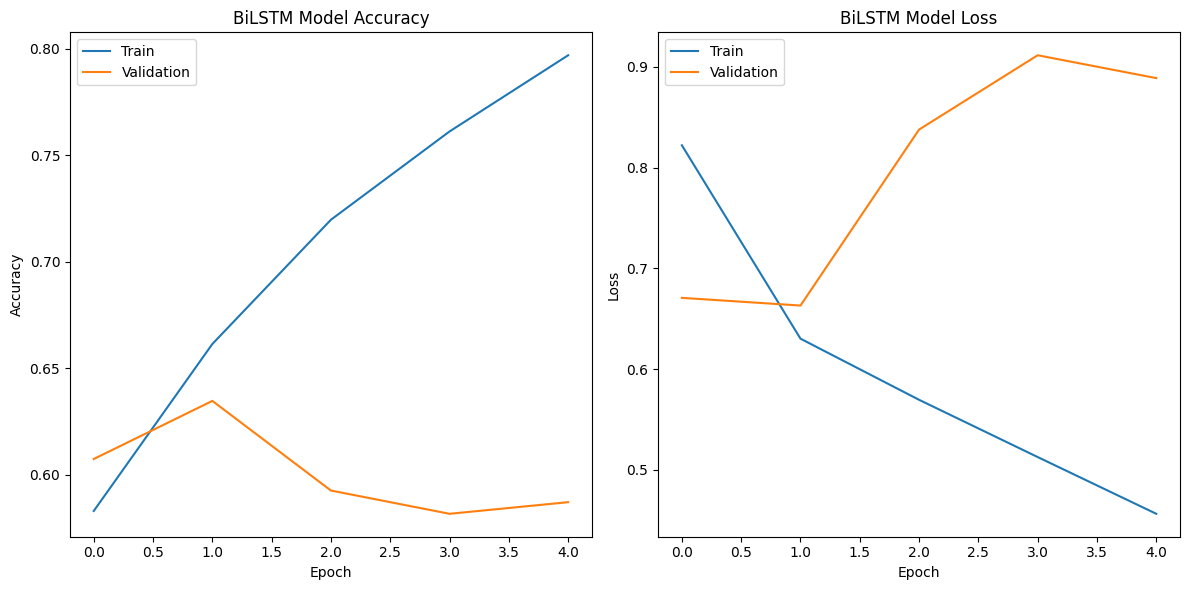

In [ ]:
import matplotlib.pyplot as plt

# Plotting for BiLSTM model (using 'history' object)
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('BiLSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('BiLSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

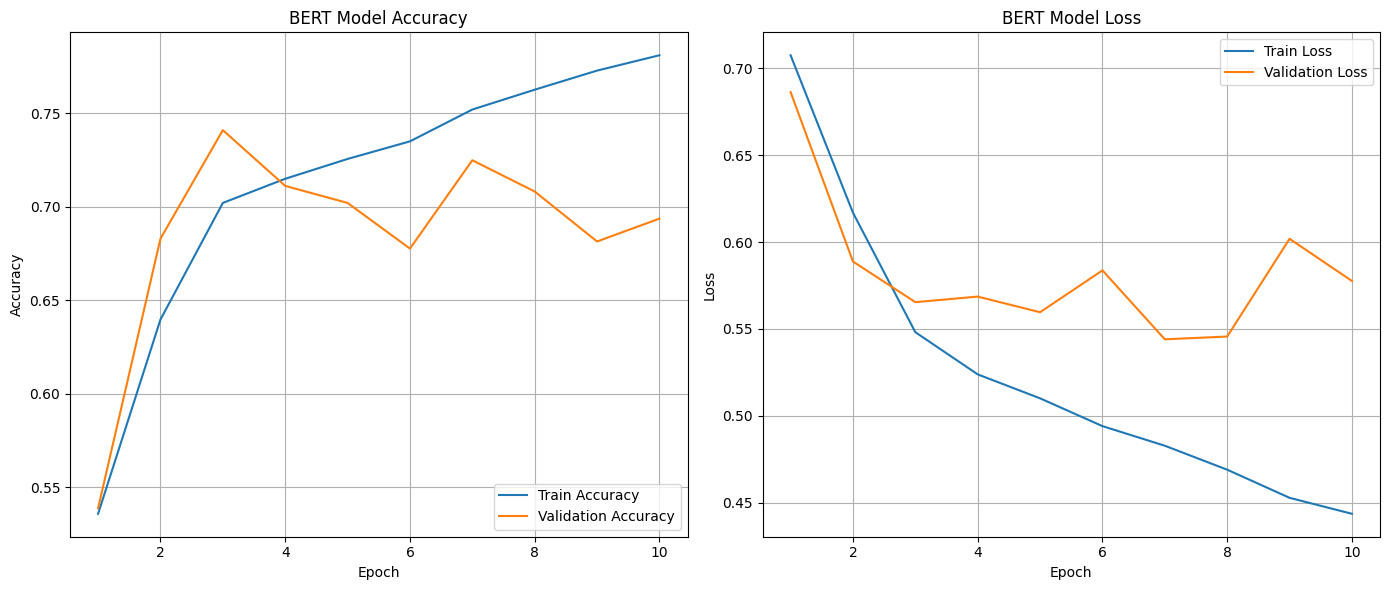

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Use the history lists generated during the BERT training loop
epochs_run = range(1, len(train_accuracy_history) + 1) # Dynamically generate epoch numbers

plt.figure(figsize=(14, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(epochs_run, train_accuracy_history, label='Train Accuracy')
plt.plot(epochs_run, val_accuracy_history, label='Validation Accuracy')
plt.title('BERT Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(epochs_run, train_loss_history, label='Train Loss')
plt.plot(epochs_run, val_loss_history, label='Validation Loss')
plt.title('BERT Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Calculate precision, recall, and F1-score
precision = precision_score(all_true_labels, all_predictions)
recall = recall_score(all_true_labels, all_predictions)
f1 = f1_score(all_true_labels, all_predictions)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Or a more comprehensive report
print("\nClassification Report:")
print(classification_report(all_true_labels, all_predictions, target_names=class_names))

Precision: 0.7537
Recall: 0.7157
F1-Score: 0.7342

Classification Report:
                              precision    recall  f1-score   support

False/Barely-True/Pants-Fire       0.66      0.70      0.68       553
  Half-True/Mostly-True/True       0.75      0.72      0.73       714

                    accuracy                           0.71      1267
                   macro avg       0.70      0.71      0.71      1267
                weighted avg       0.71      0.71      0.71      1267



### Comparison of BERT Model Performance Metrics

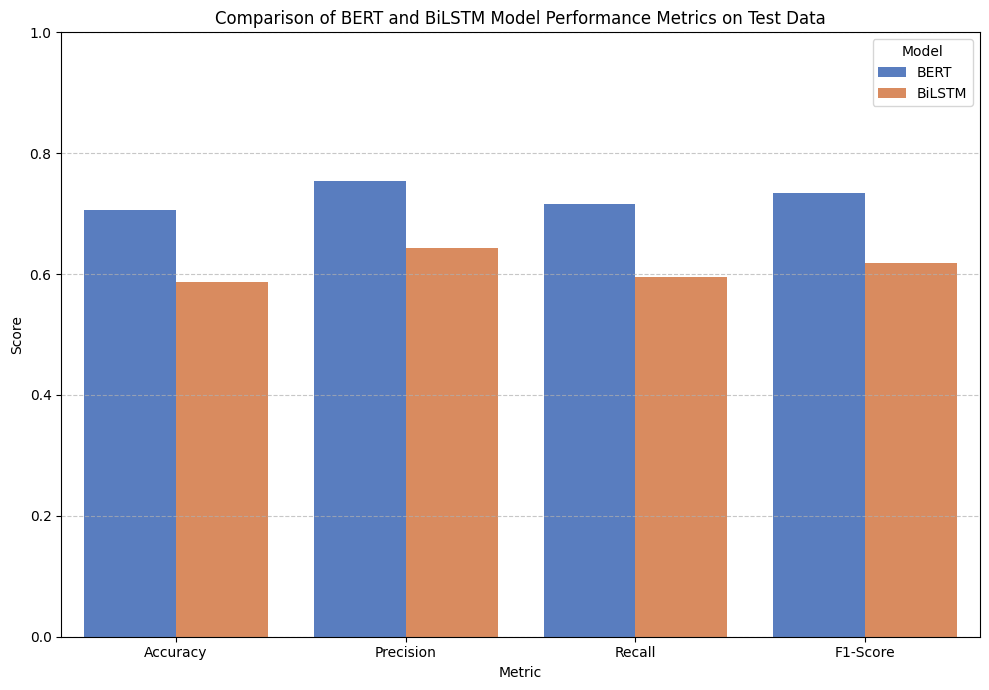

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Metrics for BERT model (from previous cell outputs)
bert_accuracy = test_accuracy / len(test_dataloader)
bert_precision = precision
bert_recall = recall
bert_f1 = f1

# Metrics for BiLSTM model (from previous cell outputs)
# test_acc is the accuracy of BiLSTM
bilstm_accuracy = test_acc

# Create a DataFrame for BERT metrics
bert_metrics_df = pd.DataFrame({
    'Model': 'BERT',
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [bert_accuracy, bert_precision, bert_recall, bert_f1]
})

# Create a DataFrame for BiLSTM metrics
bilstm_metrics_df = pd.DataFrame({
    'Model': 'BiLSTM',
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [bilstm_accuracy, bilstm_precision, bilstm_recall, bilstm_f1]
})

# Combine both DataFrames
combined_metrics_df = pd.concat([bert_metrics_df, bilstm_metrics_df])

plt.figure(figsize=(10, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=combined_metrics_df, palette='muted')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.title('Comparison of BERT and BiLSTM Model Performance Metrics on Test Data')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

### ROC Curve for BERT Model

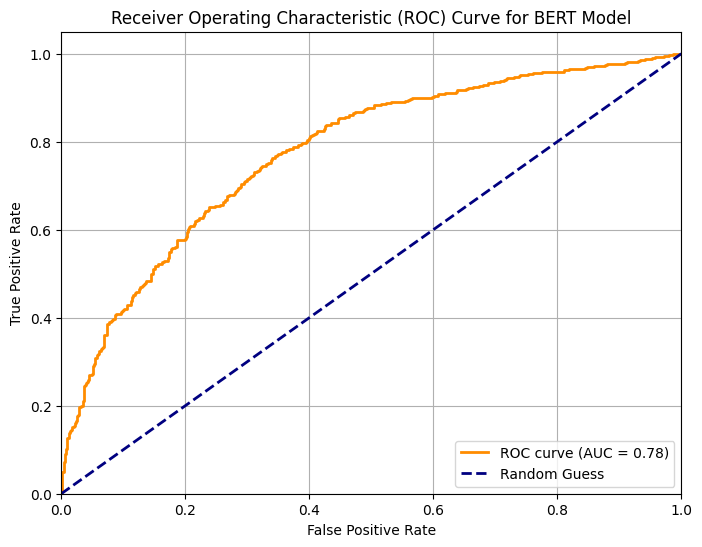

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
bert_model.eval()

all_probabilities = []
all_true_labels_roc = [] # Use a new variable to avoid confusion with previous all_true_labels

for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask
        )

    # Get logits
    logits = outputs.logits

    # Apply softmax to get probabilities for each class
    probabilities = torch.softmax(logits, dim=1)[:, 1].cpu().numpy() # Probability of the positive class (1)

    all_probabilities.extend(probabilities)
    all_true_labels_roc.extend(batch_labels.cpu().numpy())

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(all_true_labels_roc, all_probabilities)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for BERT Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Prediction Probability Distribution for BERT Model

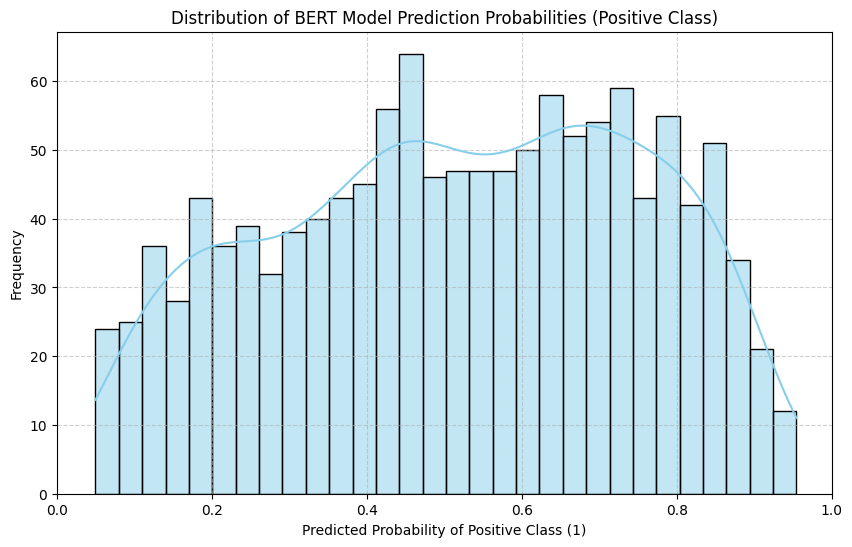

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# `all_probabilities` should already be available from the ROC curve generation cell

plt.figure(figsize=(10, 6))
sns.histplot(all_probabilities, bins=30, kde=True, color='skyblue')
plt.title('Distribution of BERT Model Prediction Probabilities (Positive Class)')
plt.xlabel('Predicted Probability of Positive Class (1)')
plt.ylabel('Frequency')
plt.xlim([0, 1])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Precision-Recall Curve for BERT Model

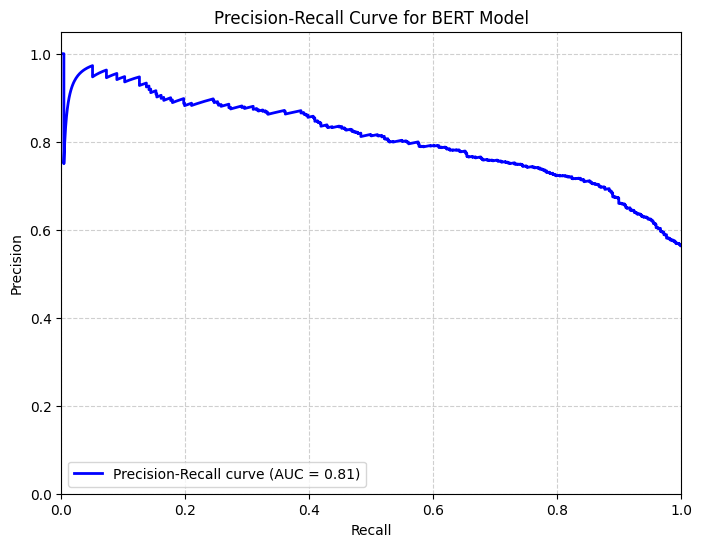

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# `all_probabilities` and `all_true_labels_roc` should be available from previous cells

# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(all_true_labels_roc, all_probabilities)
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for BERT Model')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

### ROC Curve for BiLSTM Model

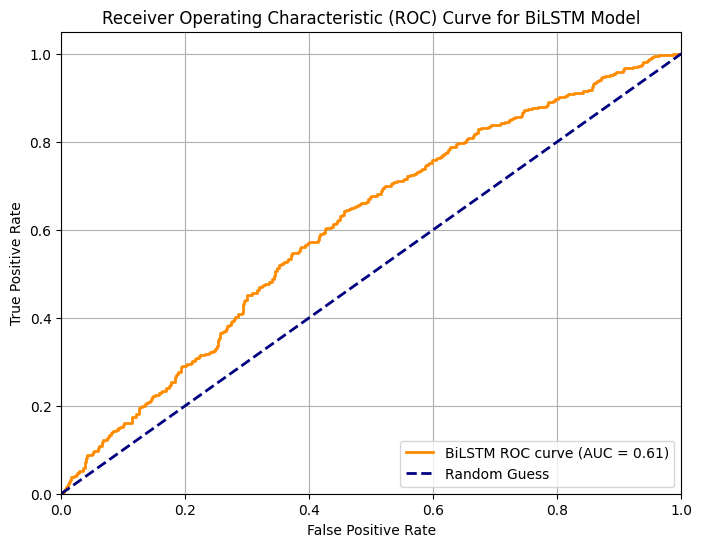

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# BiLSTM predictions (probabilities for the positive class)
bilstm_probabilities = bilstm_predictions_prob.flatten()

# Calculate ROC curve and AUC for BiLSTM
fpr_bilstm, tpr_bilstm, _ = roc_curve(test_labels, bilstm_probabilities)
roc_auc_bilstm = auc(fpr_bilstm, tpr_bilstm)

# Plot ROC curve for BiLSTM
plt.figure(figsize=(8, 6))
plt.plot(fpr_bilstm, tpr_bilstm, color='darkorange', lw=2, label=f'BiLSTM ROC curve (AUC = {roc_auc_bilstm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for BiLSTM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Precision-Recall Curve for BiLSTM Model

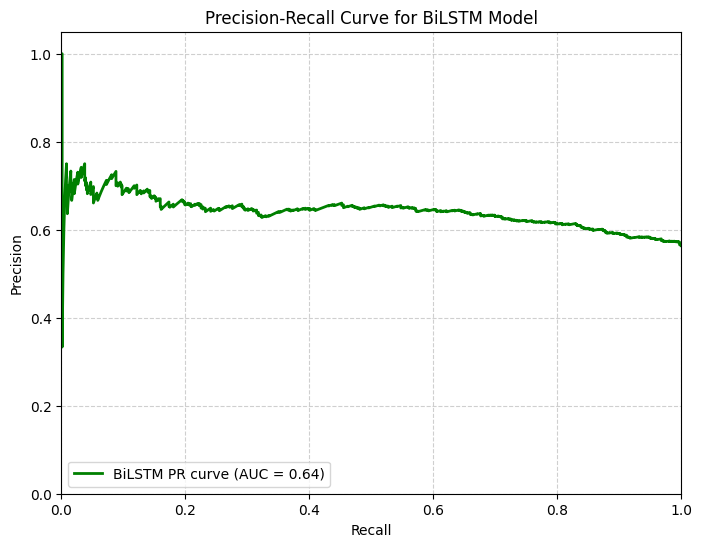

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision-recall curve for BiLSTM
precision_bilstm, recall_bilstm, _ = precision_recall_curve(test_labels, bilstm_probabilities)
pr_auc_bilstm = auc(recall_bilstm, precision_bilstm)

# Plot the Precision-Recall curve for BiLSTM
plt.figure(figsize=(8, 6))
plt.plot(recall_bilstm, precision_bilstm, color='green', lw=2, label=f'BiLSTM PR curve (AUC = {pr_auc_bilstm:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for BiLSTM Model')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

### Embeddings Visualization (PCA)

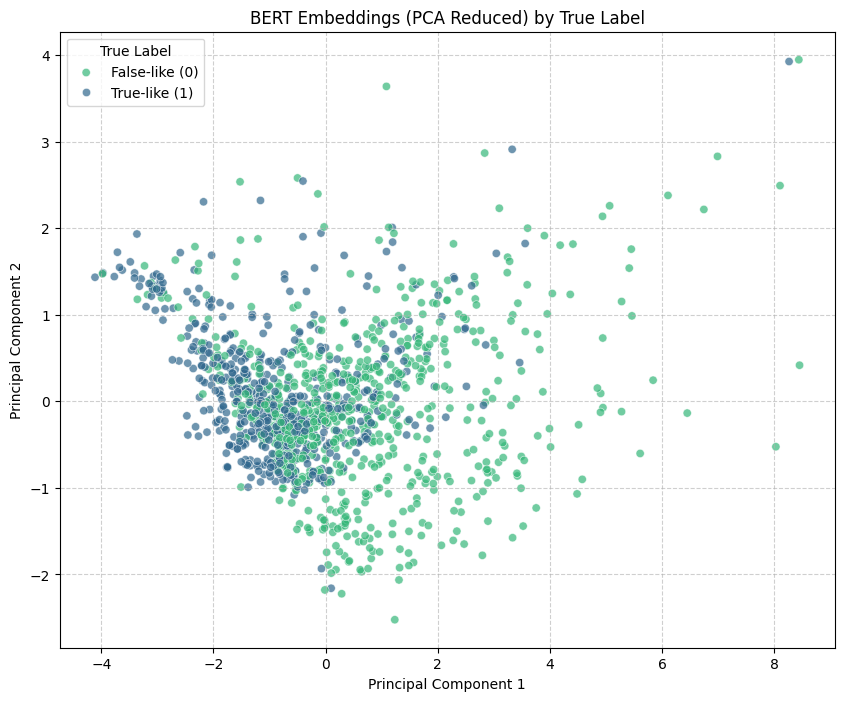

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

# Set model to evaluation mode
bert_model.eval()

all_embeddings = []
all_true_labels = []

# Iterate through the test dataloader to get embeddings
for batch in test_dataloader:
    batch_token_ids = batch[0].to(device)
    batch_attention_mask = batch[1].to(device)
    batch_labels = batch[2].to(device)

    with torch.no_grad():
        # Get model outputs with hidden states
        outputs = bert_model(
            input_ids=batch_token_ids,
            attention_mask=batch_attention_mask,
            output_hidden_states=True # Request hidden states
        )

    # The last hidden state is typically the embeddings before the classification head
    # For Roberta, this is usually outputs.hidden_states[-1]
    last_hidden_state = outputs.hidden_states[-1][:, 0, :].cpu().numpy() # [:,0,:] takes the CLS token embedding

    all_embeddings.extend(last_hidden_state)
    all_true_labels.extend(batch_labels.cpu().numpy())

all_embeddings = np.array(all_embeddings)
all_true_labels = np.array(all_true_labels)

# Apply PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Create a DataFrame for plotting
df_pca = pd.DataFrame({
    'PCA1': reduced_embeddings[:, 0],
    'PCA2': reduced_embeddings[:, 1],
    'Label': all_true_labels
})

# Plot the reduced embeddings
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Label', data=df_pca, palette='viridis', alpha=0.7)
plt.title('BERT Embeddings (PCA Reduced) by True Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='True Label', loc='best', labels=['False-like (0)', 'True-like (1)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Distribution of Statement Lengths by Label Class

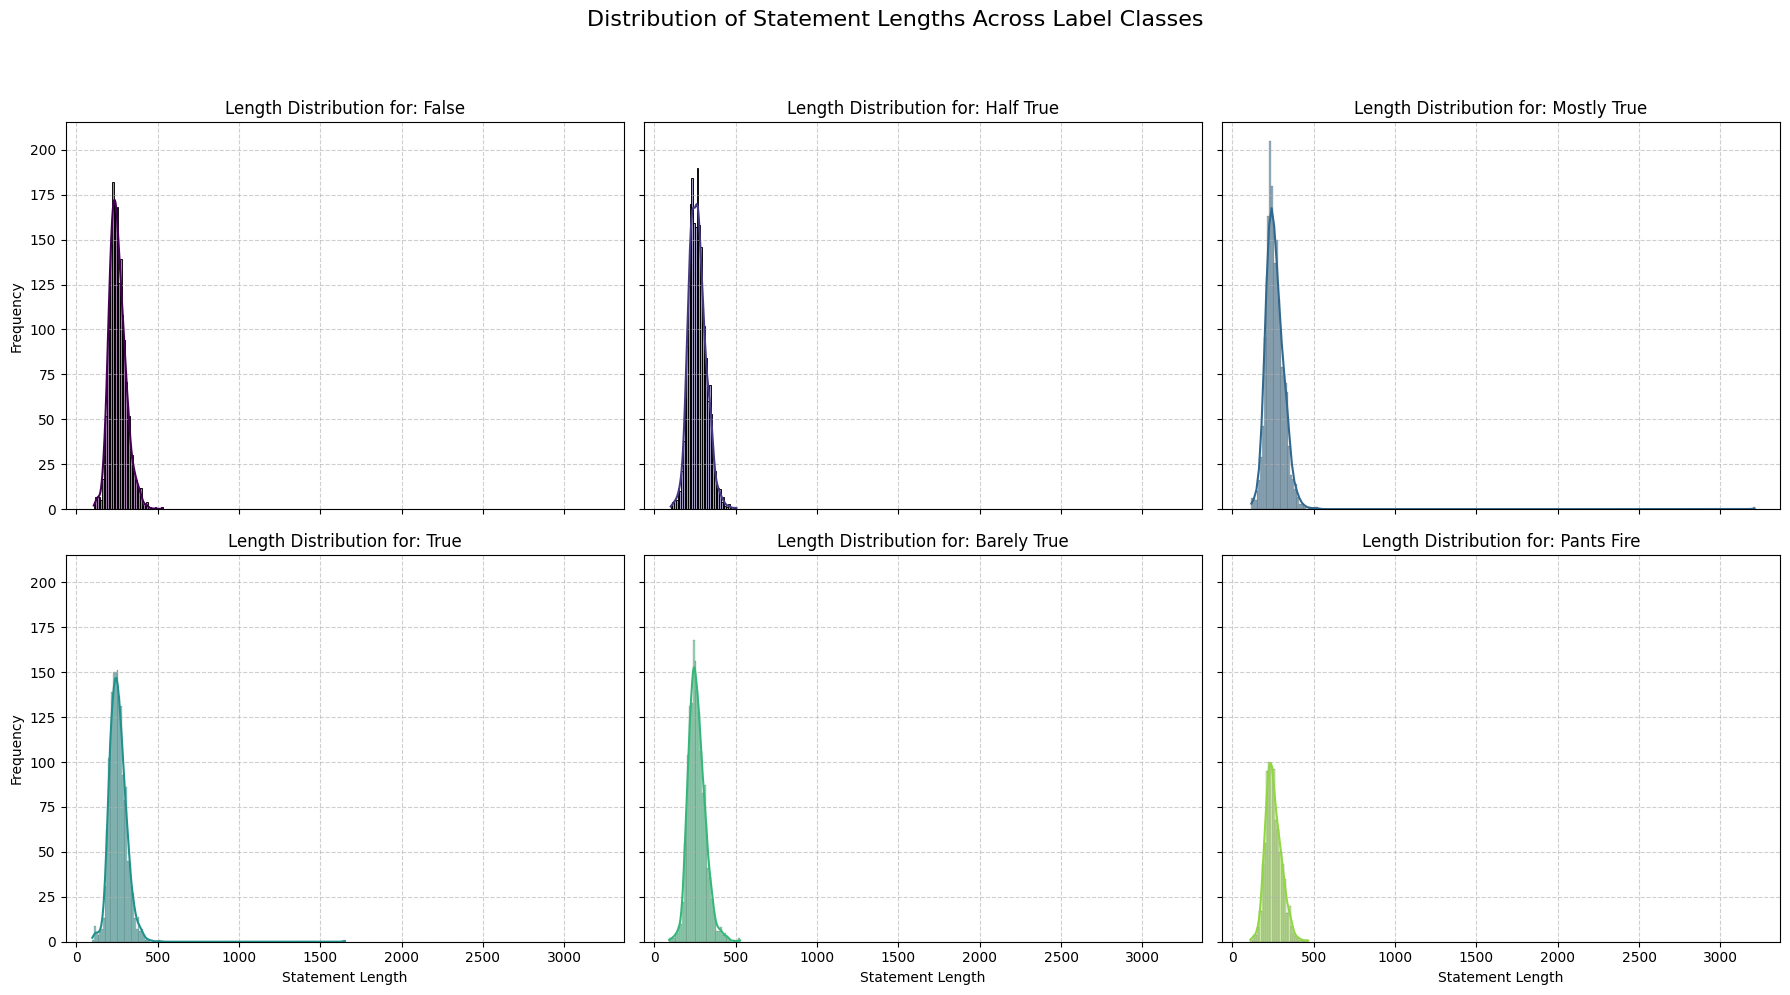

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate statement lengths
train_clean['statement_length'] = train_clean['text'].apply(len)

# Get unique labels
unique_labels = train_clean['label'].unique()

# Create a figure with subplots for each label
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, label in enumerate(unique_labels):
    sns.histplot(train_clean[train_clean['label'] == label]['statement_length'],
                 ax=axes[i], kde=True, color=plt.cm.viridis(i/len(unique_labels)))
    axes[i].set_title(f'Length Distribution for: {label.replace("-", " ").title()}')
    axes[i].set_xlabel('Statement Length')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Distribution of Statement Lengths Across Label Classes', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Error Analysis

In [ ]:
# Ensure all_predictions and all_true_labels are numpy arrays for element-wise comparison
all_predictions_np = np.array(all_predictions)
all_true_labels_np = np.array(all_true_labels)

# Identify misclassified indices
misclassified_indices = np.where(all_predictions_np != all_true_labels_np)[0]

# Create a DataFrame for misclassified statements
misclassified_df = test_clean.iloc[misclassified_indices].copy()
misclassified_df['true_binary_label'] = all_true_labels_np[misclassified_indices]
misclassified_df['predicted_binary_label'] = all_predictions_np[misclassified_indices]

print(f"Total misclassified statements: {len(misclassified_df)}")
display(misclassified_df.head())

# Analyze the types of misclassifications
misclassification_types = misclassified_df.groupby(['true_binary_label', 'predicted_binary_label']).size().unstack(fill_value=0)
print("\nMisclassification Types (True Label vs. Predicted Label):")
display(misclassification_types)

# Further analysis could involve looking at specific examples or common words in misclassified statements.

Total misclassified statements: 370


,label,statement,subject,speaker,job,party,pants_fire_counts,false_counts,barely_true_counts,half_true_counts,true_counts,text,true_binary_label,predicted_binary_label
0,true,Building a wall on the U.S.-Mexico border will take literally years.,immigration,rick-perry,Governor,republican,30,30,42,23,18,speaker rickperry party republican job governor subject immigration history 30 pantsfire 30 false 42 barelytrue 23 halftrue 18 true statement building a wall on the usmexico border will take literally years,1,0
3,half-true,Suzanne Bonamici supports a plan that will cut choice for Medicare Advantage seniors.,"medicare,message-machine-2012,campaign-advertising",rob-cornilles,consultant,republican,1,1,3,1,1,speaker robcornilles party republican job consultant subject medicaremessagemachine2012campaignadvertising history 1 pantsfire 1 false 3 barelytrue 1 halftrue 1 true statement suzanne bonamici supports a plan that will cut choice for medicare advantage seniors,1,0
9,barely-true,We know that more than half of Hillary Clintons meetings while she was secretary of state were given to major contributors to the Clinton Foundation.,foreign-policy,mike-pence,Governor,republican,8,10,12,5,0,speaker mikepence party republican job governor subject foreignpolicy history 8 pantsfire 10 false 12 barelytrue 5 halftrue 0 true statement we know that more than half of hillary clintons meetings while she was secretary of state were given to major contributors to the clinton foundation,0,1
10,barely-true,We know there are more Democrats in Georgia than Republicans. We know that for a fact.,elections,mike-berlon,NaN,democrat,1,0,0,0,0,speaker mikeberlon party democrat subject elections history 1 pantsfire 0 false 0 barelytrue 0 halftrue 0 true statement we know there are more democrats in georgia than republicans we know that for a fact,0,1
14,half-true,On residency requirements for public workers,"city-government,county-government,unions",chris-abele,Philanthropist,none,3,5,4,4,2,speaker chrisabele party none job philanthropist subject citygovernmentcountygovernmentunions history 3 pantsfire 5 false 4 barelytrue 4 halftrue 2 true statement on residency requirements for public workers,1,0



Misclassification Types (True Label vs. Predicted Label):


predicted_binary_label,0,1
true_binary_label,,
0,0,167
1,203,0


#### Most Common Subjects in Misclassified Statements

In [ ]:
# Analyze the most common subjects in misclassified statements
common_misclassified_subjects = misclassified_df['subject'].value_counts().head(10)

print("Top 10 Most Common Subjects in Misclassified Statements:")
display(common_misclassified_subjects)

Top 10 Most Common Subjects in Misclassified Statements:


,count
subject,
health-care,12
education,11
elections,10
immigration,8
federal-budget,8
candidates-biography,8
transportation,7
economy,6
energy,5


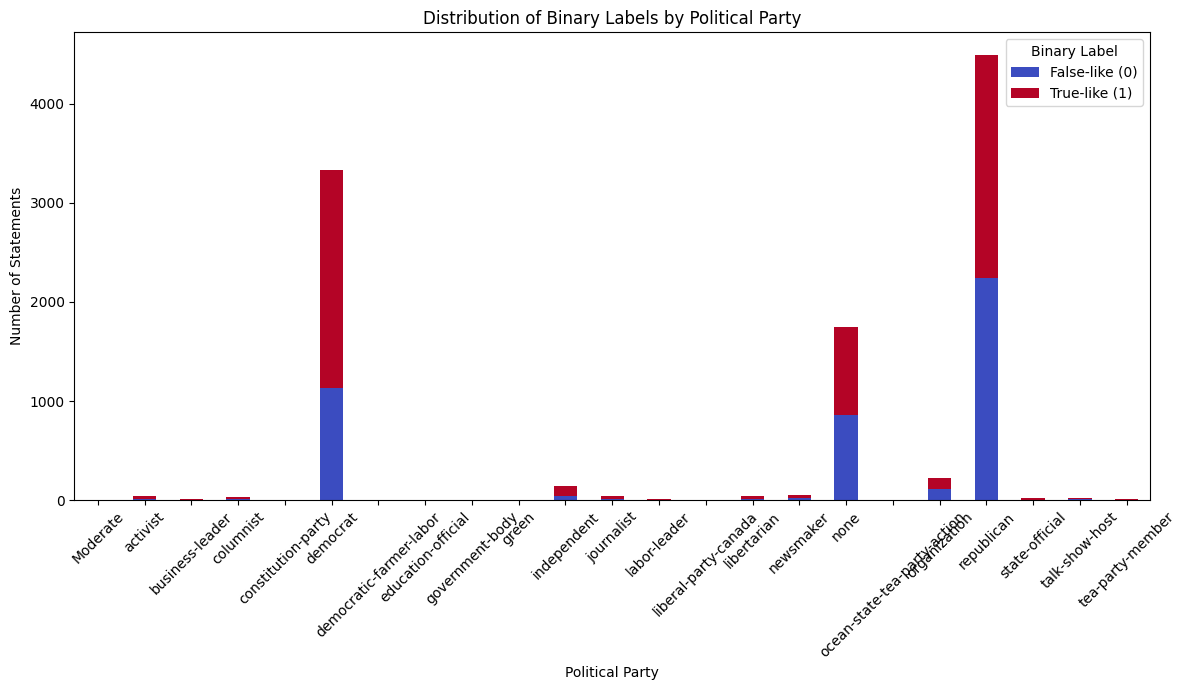

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure train_clean is available and label_map is defined (as it was in previous cells)
# Re-create label_map if the kernel state does not explicitly guarantee its presence here.
label_map = {
    'pants-fire': 0,
    'false':      0,
    'barely-true':0,
    'half-true':  1,
    'mostly-true':1,
    'true':       1
}

# Apply the binary label mapping to the train_clean DataFrame
df_party_labels = train_clean[['label', 'party']].copy()
df_party_labels['binary_label'] = df_party_labels['label'].map(label_map)

# Count the occurrences of each binary_label within each party
party_label_counts = df_party_labels.groupby(['party', 'binary_label']).size().unstack(fill_value=0)

# Rename columns for better readability in the plot
party_label_counts.rename(columns={0: 'False-like (0)', 1: 'True-like (1)'}, inplace=True)

# Plotting the stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
party_label_counts.plot(kind='bar', stacked=True, ax=ax, cmap='coolwarm')

ax.set_title('Distribution of Binary Labels by Political Party')
ax.set_xlabel('Political Party')
ax.set_ylabel('Number of Statements')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Binary Label')
plt.tight_layout()
plt.show()